# Task 1
# Formulate Research Question


### Research Question
**“Can machine learning models predict the daily Air Quality Index (AQI) of Indian cities between 2015–2020 using pollutant concentration data?”**

### Objective
The objective of this analysis is to build a **Multiple Linear Regression** model that quantifies the relationship between major pollutants and the overall Air Quality Index. This will help identify which specific pollutants are the most significant contributors to poor air quality in urban India.

### Variables
* **Dependent Variable ($y$):** `AQI` 
* **Independent Variables ($x$):**
    1. `PM2.5`: Fine particulate matter.
    2. `PM10`: Coarse particulate matter.
    3. `NO2`: Nitrogen dioxide concentration.

# Task 2
# Data Validation and Cleaning


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
print("Libraries imported successfully.")



Libraries imported successfully.


# Inspect dataset structure and data types

In [ ]:
df=pd.read_csv('city_day.csv')
df


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [8]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [34]:
# Check how many missing values you have first (Validation)
print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows where AQI is missing (you can't predict what isn't there!)
df.dropna(subset=['AQI'])

# For the pollutants,i drop them and fill them with the mean
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].mean())
df['PM10'] = df['PM10'].fillna(df['PM10'].mean())
df['NO2'] = df['NO2'].fillna(df['NO2'].mean())

print("\nMissing values after cleaning:")
print(df[['AQI', 'PM2.5', 'PM10', 'NO2']].isnull().sum())

Missing values before cleaning:
City              0
Date              0
PM2.5             0
PM10              0
NO             3582
NO2               0
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Missing values after cleaning:
AQI      4681
PM2.5       0
PM10        0
NO2         0
dtype: int64


In [16]:
df.duplicated().sum()

np.int64(0)

# Summarize Findings

After Cleaning the Data set i discovered that there are many missing values and duplicate data , there are 29531 rows and  16 columns at the begining , however i drop the values or data that i will not use as variables after cleaning the missing values of AQI is 4681 while the other variables are 0.

# Task 3

# Exploratory Data Analysis (EDA)

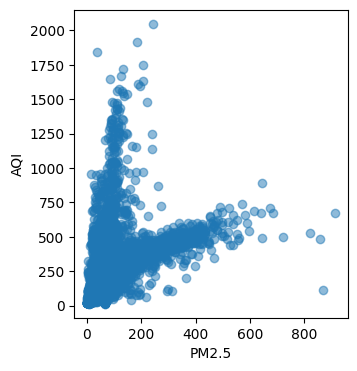

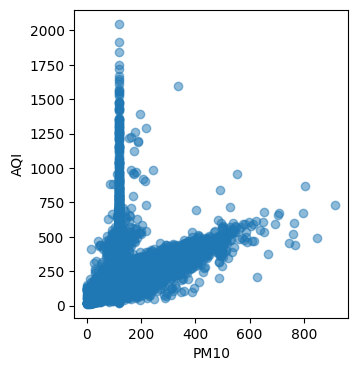

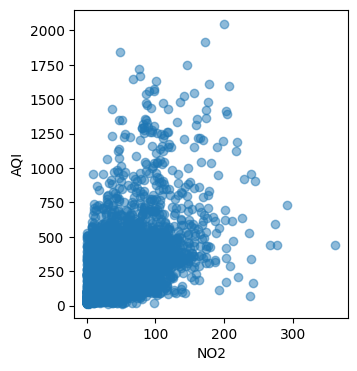

In [23]:
# A Scatter

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(df['PM2.5'], df['AQI'], alpha=0.5)
plt.xlabel('PM2.5')
plt.ylabel('AQI')


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 2)
plt.scatter(df['PM10'], df['AQI'], alpha=0.5)
plt.xlabel('PM10')
plt.ylabel('AQI')


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 3)
plt.scatter(df['NO2'], df['AQI'], alpha=0.5)
plt.xlabel('NO2')
plt.ylabel('AQI')

plt.show()

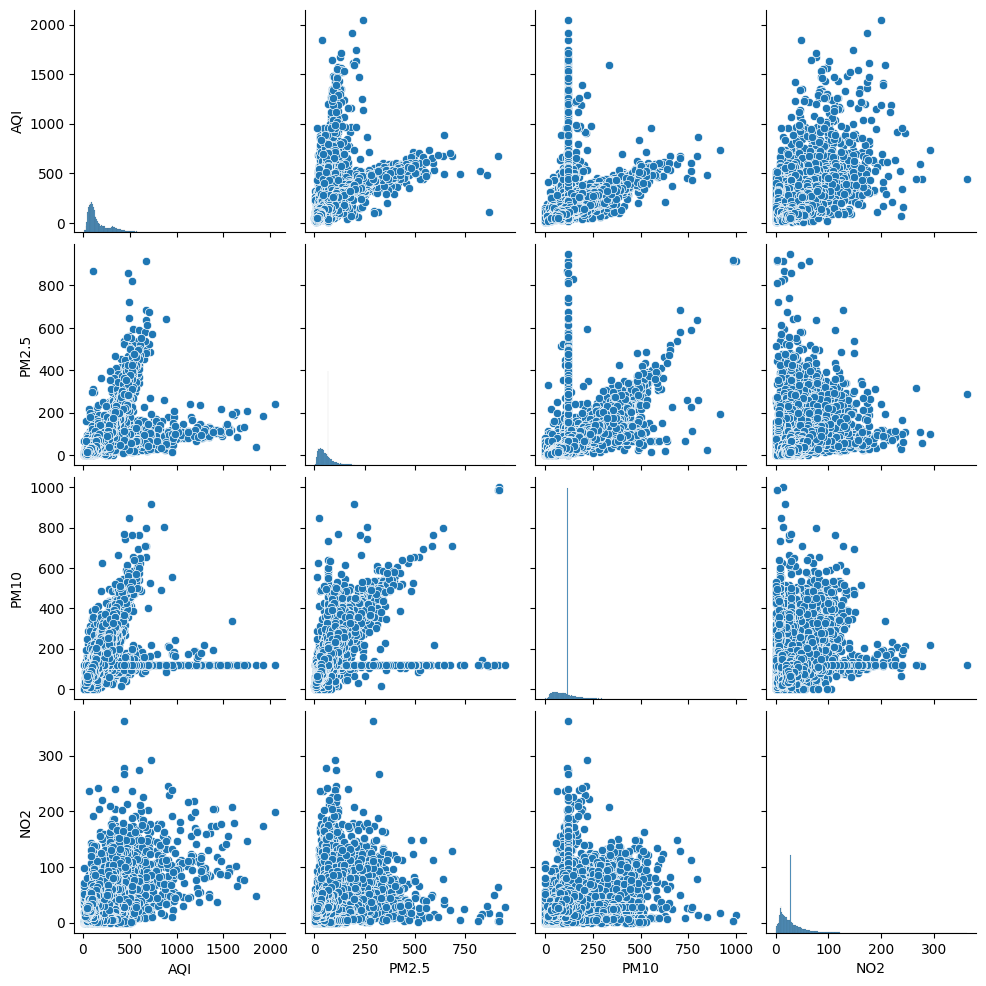

In [ ]:
#Pair Plot
sns.pairplot(df[['AQI', 'PM2.5', 'PM10', 'NO2']])
plt.show()

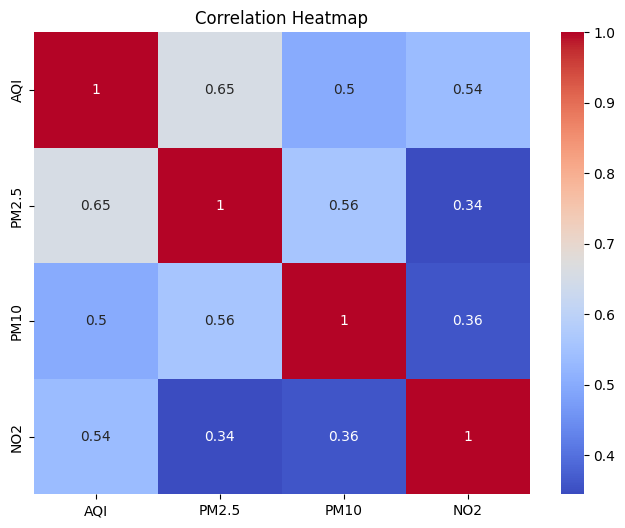

In [27]:
#correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['AQI', 'PM2.5', 'PM10', 'NO2']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Explanation of visualization


# Task 4


# Model Training


In [37]:

# Independent and dependent variables
x = df[["PM2.5", "PM10", "NO2"]].fillna(df[["PM2.5", "PM10", "NO2"]].mean())
y = df["AQI"].fillna(df["AQI"].mean())
#fill missing values (with mean or median)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Model training
model = LinearRegression()
model.fit(x_train, y_train)

# Intercept and coefficients
print("Intercept:", model.intercept_)
coefficients = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
print(coefficients)

# Predictions
y_pred = model.predict(x_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())



Intercept: 23.007800517236035
       Coefficient
PM2.5     0.966936
PM10      0.212849
NO2       1.862532
           Actual   Predicted
22593  166.463581  166.566593
22459  166.463581  166.566593
24213  137.000000  136.472994
25301  190.000000  134.274026
20886  339.000000  336.537250


# Task 5 
# Performance Evaluation

In [ ]:
mae=mean_squared_error(y_test, y_pred)
mse=root_mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")


NameError: name 'mean_squared_error' is not defined

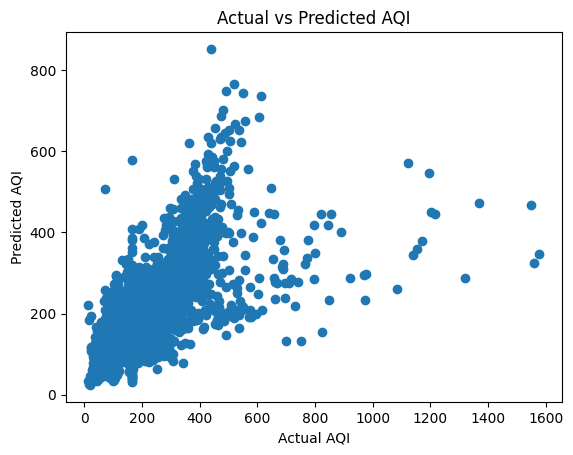

In [41]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.show()

In [1]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.AxLine(y=0, color='red', linestyle='--')
plt.xlabel('Predicted AQI')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted AQI')
plt.show()


NameError: name 'y_test' is not defined

# Explanation

In [43]:
new_data = pd.DataFrame({
    'PM2.5': [35],
    'PM10': [50],
    'NO2': [20]
})
predicted_aqi = model.predict(new_data)
print("Predicted AQI for new data:", predicted_aqi[0])


Predicted AQI for new data: 104.74365527153313
